# Trader Behavior Analysis: Fear vs Greed

This notebook analyzes the relationship between Bitcoin market sentiment (Fear vs Greed) and trader behavior using historical Hyperliquid trading data.

## 1. Data Loading

In this section, we load:
- Historical Hyperliquid trading data  
- Bitcoin Fear & Greed Index data  
into Pandas DataFrames for further analysis.

In [116]:
# Core data science libraries
import pandas as pd
import numpy as np

# Load datasets
historical_df = pd.read_csv("data/historical_data.csv")
fear_greed_df = pd.read_csv("data/fear_greed_index.csv")

print("Historical data shape:", historical_df.shape)
print("Fear & Greed data shape:", fear_greed_df.shape)

Historical data shape: (211224, 16)
Fear & Greed data shape: (2644, 4)


In [117]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [118]:
fear_greed_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [119]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [120]:
fear_greed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


## 2. Data Preprocessing

In this section we:
- Convert timestamps to proper datetime format  
- Create a common `date` column in both datasets  
- Prepare both datasets for merging  

In [121]:
# Convert trading timestamp to datetime (IST format: DD-MM-YYYY)
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Verify conversion
historical_df[['Timestamp IST']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 1 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp IST  211224 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [122]:
# Create a pure date column (YYYY-MM-DD) for merging
historical_df['date'] = historical_df['Timestamp IST'].dt.date

# Check result
historical_df[['Timestamp IST', 'date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp IST  211224 non-null  datetime64[ns]
 1   date           211224 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 3.2+ MB


In [123]:
# Convert Fear & Greed date column to datetime
fear_greed_df['date'] = pd.to_datetime(
    fear_greed_df['date'],
    dayfirst=True,
    errors='coerce'
)

# Verify
fear_greed_df[['date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1046 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 20.8 KB


In [124]:
# Convert date column of fear_greed_df to plain Python date (for clean merging)
fear_greed_df['date'] = fear_greed_df['date'].dt.date

print("historical_df date dtype:", historical_df['date'].dtype)
print("fear_greed_df date dtype:", fear_greed_df['date'].dtype)

historical_df date dtype: object
fear_greed_df date dtype: object


## 3. Data Merging

In this section we:
- Left-merge the trading data with the Fear & Greed dataset on `date`
- Create a master dataset (`merged_df`) containing sentiment for each trade  
- Create a cleaned version (`merged_clean`) that excludes rows without sentiment

In [125]:
# Left merge: keep all trades, attach sentiment where available
merged_df = historical_df.merge(
    fear_greed_df[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged data shape:", merged_df.shape)

# Check how many trades got each sentiment label (including NaN)
print("\nSentiment distribution after merge:")
print(merged_df['classification'].value_counts(dropna=False))

Merged data shape: (211224, 18)

Sentiment distribution after merge:
classification
NaN              175360
Fear              13869
Greed             11292
Extreme Greed      5621
Neutral            2756
Extreme Fear       2326
Name: count, dtype: int64


In [126]:
# Create a cleaned dataset with only trades that have sentiment labels
merged_clean = merged_df.dropna(subset=['classification'])

print("Cleaned data shape:", merged_clean.shape)

# Confirm no NaN remain in classification
print("\nSentiment distribution (cleaned):")
print(merged_clean['classification'].value_counts())

Cleaned data shape: (35864, 18)

Sentiment distribution (cleaned):
classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


In [127]:
merged_clean[['Timestamp IST', 'Closed PnL', 'classification']].head()

,Timestamp IST,Closed PnL,classification
0,2024-12-02 22:50:00,0.0,Greed
1,2024-12-02 22:50:00,0.0,Greed
2,2024-12-02 22:50:00,0.0,Greed
3,2024-12-02 22:50:00,0.0,Greed
4,2024-12-02 22:50:00,0.0,Greed


## 4. Exploratory Data Analysis

In this section we examine how trader behavior varies across different market sentiment regimes:
- Profitability (Closed PnL)
- Trading activity (number of trades)
- Position size (risk-taking)
- Win rate
- Profit vs loss profile

### 4.1 Profitability vs Market Sentiment

We compute the average Closed PnL per trade for each sentiment category.

In [128]:
avg_pnl_by_sentiment = (
    merged_clean
    .groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

print(avg_pnl_by_sentiment)

classification
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Extreme Fear       1.891632
Name: Closed PnL, dtype: float64


### 4.2 Trading Activity vs Market Sentiment

We analyze how many trades occurred under each sentiment regime.

In [129]:
trade_counts = (
    merged_clean['classification']
    .value_counts()
    .sort_values(ascending=False)
)

print(trade_counts)

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64


### 4.3 Position Size (Risk-Taking) vs Market Sentiment

We use `Start Position` as a proxy for risk-taking and compute its average across sentiments.

In [130]:
avg_position_by_sentiment = (
    merged_clean
    .groupby('classification')['Start Position']
    .mean()
    .sort_values(ascending=False)
)

print(avg_position_by_sentiment)

classification
Neutral          89199.587406
Greed            37276.787811
Extreme Greed    24593.241160
Extreme Fear     21902.797505
Fear              8146.358518
Name: Start Position, dtype: float64


### 4.4 Win Rate by Market Sentiment

We compute the fraction of profitable trades (Closed PnL > 0) in each sentiment category.

In [131]:
merged_clean['win'] = merged_clean['Closed PnL'] > 0

win_rate_by_sentiment = (
    merged_clean
    .groupby('classification')['win']
    .mean()
    .sort_values(ascending=False)
)

print(win_rate_by_sentiment)

classification
Extreme Greed    0.553282
Neutral          0.494920
Greed            0.435707
Fear             0.381787
Extreme Fear     0.292777
Name: win, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_728\553350718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['win'] = merged_clean['Closed PnL'] > 0


### 4.5 Profit vs Loss Profile by Sentiment

We compare the average size of winning trades vs losing trades for each sentiment.

In [132]:
profit_loss_summary = (
    merged_clean
    .groupby('classification')['Closed PnL']
    .agg([
        ('avg_profit', lambda x: x[x > 0].mean()),
        ('avg_loss', lambda x: x[x < 0].mean())
    ])
)

print(profit_loss_summary)

                avg_profit    avg_loss
classification                        
Extreme Fear     20.288214  -66.312233
Extreme Greed   417.564586 -463.177085
Fear            373.538721 -215.936895
Greed           198.204387 -413.498928
Neutral          61.764572  -31.238223


## 5. Visualizations

We create clear visual summaries of:
- Average profitability by sentiment  
- Trading activity by sentiment  
- (Optional) Win rate by sentiment  

### 5.1 Average Closed PnL by Market Sentiment

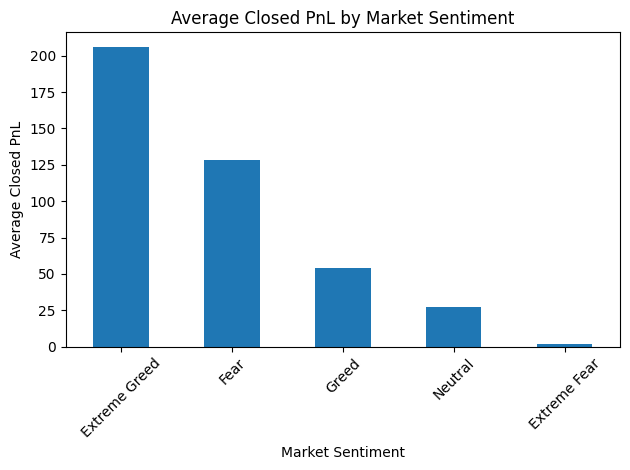

In [133]:
import matplotlib.pyplot as plt

avg_pnl_by_sentiment.plot(kind='bar')
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Number of Trades by Market Sentiment

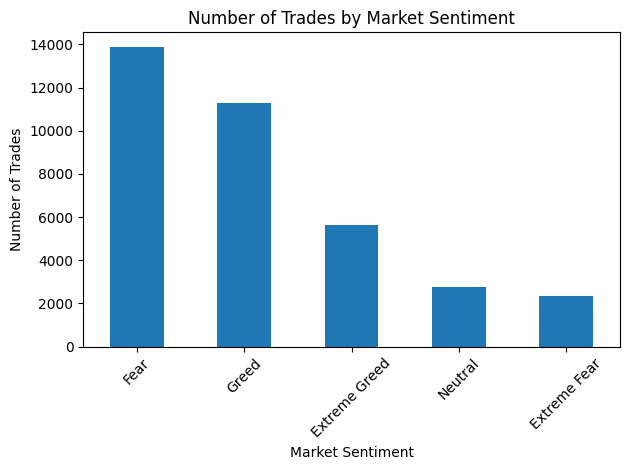

In [134]:
trade_counts.plot(kind='bar')
plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Number of Trades")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Win Rate by Market Sentiment

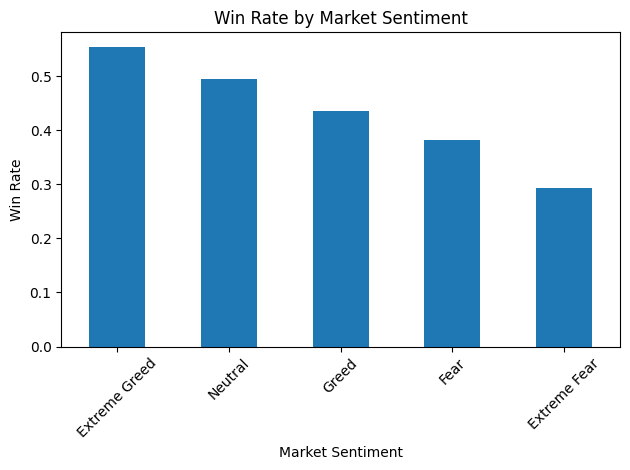

In [135]:
win_rate_by_sentiment.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Key Insights & Conclusion

### Summary of Findings

Based on the analysis of trading behavior across different market sentiment regimes (Fear vs Greed), we observe the following key patterns:

**1. Profitability and Sentiment**
- Traders were most profitable on average during **Extreme Greed** conditions.
- Profitability was also relatively strong during **Fear**, but much lower during **Neutral and Greed**.
- **Extreme Fear** days produced near-zero average profits, indicating very poor trading performance under panic conditions.

**2. Trading Activity**
- The highest number of trades occurred during **Fear**, suggesting that market uncertainty and volatility drive increased trading activity.
- Trading activity dropped significantly during **Extreme Fear**, indicating that many traders step back during extreme panic.
- Greed conditions also saw high activity, but slightly less than Fear.

**3. Risk-Taking (Position Size)**
- Traders took the **largest positions during Neutral markets**, likely due to perceived lower risk and market stability.
- Position sizes dropped sharply during **Fear**, reflecting strong risk aversion.
- Both **Extreme Fear and Extreme Greed** were associated with moderately reduced position sizes compared to Neutral and Greed.

**4. Win Rate**
- The highest win rate was observed during **Extreme Greed**, aligning with its strong profitability.
- Win rates declined progressively from Neutral → Greed → Fear → Extreme Fear.
- Traders performed worst during **Extreme Fear**, confirming that panic conditions are the most challenging for profitable trading.

**5. Profit vs Loss Behavior**
- **Extreme Greed** exhibited high average profits but also very large losses, indicating aggressive risk-taking.
- **Fear** showed a relatively better risk-adjusted profile, with large average wins compared to losses.
- **Greed** displayed a poor risk profile, where average losses were substantially larger than average profits.
- **Neutral** markets showed small wins and small losses, indicating low-risk, low-reward behavior.

---

### Overall Conclusion

Trader behavior is strongly influenced by market sentiment. While **Extreme Greed** delivered the best average profitability and highest win rate, traders were **most active during Fear** but took the **smallest positions** in those conditions. Conversely, traders took their **largest positions in Neutral markets**, even though profitability was relatively low.

These results highlight the complex relationship between sentiment, risk-taking, and trading performance, suggesting that neither pure fear nor pure greed alone guarantees optimal trading outcomes.